In [2]:
pip install cvxpy numpy pandas matplotlib pandas

In [3]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv("../dataset/majorproject_df.csv")

In [5]:
def predict_load(user_input):
    import pandas as pd
    import pickle
    import os


    BASE_PATH = os.path.abspath("../models-encoders")

    with open(os.path.join(BASE_PATH, "load-encoder.pickle"), "rb") as f:
        scaler = pickle.load(f)

    with open(os.path.join(BASE_PATH, "load-ohe.pickle"), "rb") as f:
        encoder = pickle.load(f)

    with open(os.path.join(BASE_PATH, "load-model.pickle"), "rb") as f:
        final_model = pickle.load(f)

    EXPECTED_COLS = [
    "temp_C", "humidity_%", "wind_speed_m_s",
    "solar_irradiance_W_m2", "precip_mm",
    "year", "month", "day", "hour",
    "weather_Cloudy", "weather_Rainy", "weather_Sunny"
    ]


    df = pd.DataFrame([user_input])

    df["datetime"] = pd.to_datetime(df["datetime"])
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day
    df["hour"] = df["datetime"].dt.hour

    df = df.drop(columns=["datetime"], errors="ignore")

    weather_ohe = encoder.transform(df[["weather"]])
    weather_df = pd.DataFrame(
        weather_ohe,
        columns=encoder.get_feature_names_out(["weather"])
    )

    df = pd.concat([df.drop(columns=["weather"]), weather_df], axis=1)

    for col in EXPECTED_COLS:
        if col not in df.columns:
            df[col] = 0

    df = df[EXPECTED_COLS]

    X_scaled = scaler.transform(df)
    prediction_scaled = final_model.predict(X_scaled)


    prediction_real = float(prediction_scaled[0])

    return prediction_real



In [6]:
def predict_solar(user_input):
    import pickle
    import pandas as pd
    import os

    BASE_PATH = os.path.abspath("../models-encoders")

    # --------------------------------------------
    # Load saved objects
    # --------------------------------------------
    with open(os.path.join(BASE_PATH, "solar-encoder.pickle"), "rb") as f:
        scaler = pickle.load(f)

    with open(os.path.join(BASE_PATH, "solar-ohe.pickle"), "rb") as f:
        encoder = pickle.load(f)

    with open(os.path.join(BASE_PATH, "solar-model.pickle"), "rb") as f:
        final_model = pickle.load(f)

    # Expected column order during training
    EXPECTED_COLS = [
        'temp_C', 'humidity_%', 'wind_speed_m_s', 'solar_irradiance_W_m2','precip_mm',
        'installed_solar_MW', 'panel_area_m2', 'num_panels', 'year', 'month', 'day', 'hour',
        'weather_Cloudy', 'weather_Rainy', 'weather_Sunny'
    ]

    # --------------------------------------------
    # Input Processing
    # --------------------------------------------
    df = pd.DataFrame([user_input])

    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year'] = df['datetime'].dt.year

    df = df.drop(columns=['datetime'], errors='ignore')

    # --------------------------------------------
    # One-hot encode weather
    # --------------------------------------------
    encoded_weather = encoder.transform(df[['weather']])
    weather_df = pd.DataFrame(
        encoded_weather,
        columns=encoder.get_feature_names_out(['weather'])
    )

    df = pd.concat([df.drop(columns=['weather']), weather_df], axis=1)

    # --------------------------------------------
    # Add missing columns
    # --------------------------------------------
    for col in EXPECTED_COLS:
        if col not in df.columns:
            df[col] = 0

    df = df[EXPECTED_COLS]

    # --------------------------------------------
    # Scale & Predict
    # --------------------------------------------
    X_scaled = scaler.transform(df)
    prediction = final_model.predict(X_scaled)

    return prediction[0]


In [7]:
def predict_wind(user_input):
    import pickle
    import pandas as pd
    import os

    BASE_PATH = os.path.abspath("../models-encoders")

    # --------------------------------------------
    # Load saved objects
    # --------------------------------------------
    with open(os.path.join(BASE_PATH, "wind-encoder.pickle"), "rb") as f:
        scaler = pickle.load(f)

    with open(os.path.join(BASE_PATH, "wind-ohe.pickle"), "rb") as f:
        encoder = pickle.load(f)

    with open(os.path.join(BASE_PATH, "wind-model.pickle"), "rb") as f:
        wind_model = pickle.load(f)

    # Columns used in training
    EXPECTED_COLS = [
        "temp_C", "humidity_%", "wind_speed_m_s",
        "precip_mm", "installed_wind_MW",
        "year", "month", "day", "hour",
        "weather_Cloudy", "weather_Rainy", "weather_Sunny"
    ]

    # --------------------------------------------
    # Convert input to DataFrame
    # --------------------------------------------
    df = pd.DataFrame([user_input])

    df["datetime"] = pd.to_datetime(df["datetime"])
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day
    df["hour"] = df["datetime"].dt.hour
    df = df.drop(columns=["datetime"], errors="ignore")

    # --------------------------------------------
    # One-hot encode weather
    # --------------------------------------------
    weather_encoded = encoder.transform(df[["weather"]])
    weather_df = pd.DataFrame(
        weather_encoded,
        columns=encoder.get_feature_names_out(["weather"])
    )

    df = pd.concat([df.drop(columns=["weather"]), weather_df], axis=1)

    # --------------------------------------------
    # Add missing columns
    # --------------------------------------------
    for col in EXPECTED_COLS:
        if col not in df.columns:
            df[col] = 0

    df = df[EXPECTED_COLS]

    # --------------------------------------------
    # Scale & Predict
    # --------------------------------------------
    df_scaled = scaler.transform(df)

    prediction = wind_model.predict(df_scaled)

    return prediction[0]


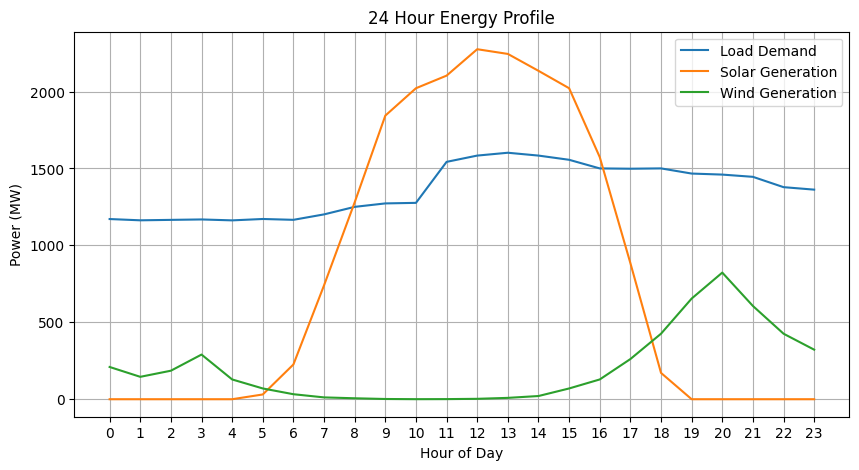

In [ ]:
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Simulation parameters
# -----------------------------
T = 48      # 1 day simulation
H=4
load = []
solar = []
wind = []

current_time = datetime(2025, 10, 13, 0, 0, 0)

# -----------------------------
# Realistic Rajasthan Weather Data
# -----------------------------

temperature = [
24,23,22,22,21,22,
24,27,30,33,35,37,
38,39,38,36,34,32,
30,28,27,26,25,24
]

humidity = [
55,57,58,60,62,60,
55,48,42,38,35,32,
30,28,30,33,37,40,
45,48,50,52,54,55
]

irradiance = [
0,0,0,0,0,10,
80,250,450,650,720,750,
810,800,760,720,550,300,
60,0,0,0,0,0
]

wind_speed = [
5.6,5.3,5.5,5.9,5.2,4.8,
4.4,4.0,3.8,3.5,3.3,3.4,
3.6,3.9,4.2,4.8,5.2,5.8,
6.3,6.8,7.1,6.7,6.3,6.0
]

temperature = temperature*2
humidity = humidity*2
irradiance = irradiance*2
wind_speed = wind_speed*2

# -----------------------------
# Simulation Loop
# -----------------------------

for i in range(T):

    dt = current_time + timedelta(hours=i)

    temp = temperature[i]
    hum = humidity[i]
    irr = irradiance[i]
    ws = wind_speed[i]

    weather = "Sunny" if irr > 200 else "Cloudy"

    # -----------------------------
    # Model Inputs
    # -----------------------------

    load_input = {
        "datetime": dt,
        "weather": weather,
        "temp_C": temp,
        "humidity_%": hum,
        "wind_speed_m_s": ws,
        "solar_irradiance_W_m2": irr,
        "precip_mm": 0
    }

    solar_input = {
        "datetime": dt,
        "weather": weather,
        "temp_C": temp,
        "humidity_%": hum,
        "wind_speed_m_s": ws,
        "solar_irradiance_W_m2": irr,
        "precip_mm": 0,
        "installed_solar_MW": 3000,
        "panel_area_m2": 12750000,
        "num_panels": 7500000
    }

    wind_input = {
        "datetime": dt,
        "weather": weather,
        "temp_C": temp,
        "humidity_%": hum,
        "wind_speed_m_s": ws,
        "precip_mm": 0,
        "installed_wind_MW": 1000
    }

    # -----------------------------
    # ML Predictions
    # -----------------------------

    load_pred = predict_load(load_input)
    solar_pred = predict_solar(solar_input)
    wind_pred = predict_wind(wind_input)

    load.append(load_pred)
    solar.append(solar_pred)
    wind.append(wind_pred)

# -----------------------------
# Convert to arrays
# -----------------------------

load = np.array(load)
solar = np.array(solar)
wind = np.array(wind)

net_generation = solar+wind
# -----------------------------
# Plot Results
# -----------------------------

hours = np.arange(24)

plt.figure(figsize=(10,5))

plt.plot(hours, load[:24], label="Load Demand")
plt.plot(hours, solar[:24], label="Solar Generation")
plt.plot(hours, wind[:24], label="Wind Generation")

plt.xlabel("Hour of Day")
plt.ylabel("Power (MW)")
plt.title("24 Hour Energy Profile")

plt.xticks(hours)
plt.grid(True)
plt.legend()

plt.show()

In [24]:
capacity = 100        # kWh
SOC = 50              # initial SOC
SOC_min = 20
SOC_max = 90

P_max = 30            # max charge/discharge power
eta_c = 0.95
eta_d = 0.95
dt = 1
            

In [34]:
import cvxpy as cp

def MPC_step(current_SOC, start_index):
    horizon = H

    # Decision variables
    P_charge = cp.Variable(horizon)      # kW, charging
    P_discharge = cp.Variable(horizon)   # kW, discharging
    SOC_var = cp.Variable(horizon+1)     # SOC fraction (0-1)

    # Initial SOC
    constraints = [SOC_var[0] == current_SOC]

    for k in range(horizon):
        # SOC dynamics with battery capacity
        constraints += [
            SOC_var[k+1] == SOC_var[k] + (eta_c*P_charge[k]*dt - (P_discharge[k]*dt)/eta_d)/capacity,
            SOC_var[k+1] >= SOC_min,
            SOC_var[k+1] <= SOC_max,
            P_charge[k] >= 0,
            P_charge[k] <= P_max,
            P_discharge[k] >= 0,
            P_discharge[k] <= P_max
        ]

    # Cost function: minimize net load deviation
    cost = 0
    for k in range(horizon):
        net_load = load[start_index + k] - net_generation[start_index + k]
        battery_power = P_discharge[k] - P_charge[k]
        cost += cp.square(net_load - battery_power)

    # Solve optimization
    problem = cp.Problem(cp.Minimize(cost), constraints)
    problem.solve(solver=cp.OSQP, verbose=False)

    # Return first control step
    return P_charge.value[0], P_discharge.value[0]

In [35]:
initial_SOC = 50   

SOC_history = []
battery_power_history = []

SOC = initial_SOC

for t in range(T-H):   # FIX HERE
    Pch, Pdis = MPC_step(SOC, t)

    battery_power = Pdis - Pch

    SOC = SOC + eta_c*Pch*dt - (Pdis*dt)/eta_d

    SOC_history.append(SOC)
    battery_power_history.append(battery_power)

TypeError: 'NoneType' object is not subscriptable

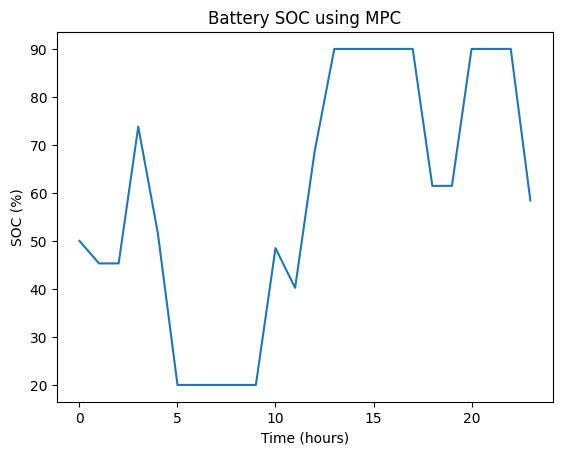

In [17]:
plt.plot(SOC_history)
plt.title("Battery SOC using MPC")
plt.ylabel("SOC (%)")
plt.xlabel("Time (hours)")
plt.show()

In [ ]:
net_load = load - net_generation
net_load_after = net_load - np.array(battery_power_history)

plt.plot(net_load[:24], label="Net Load Before Battery")
plt.plot(net_load_after[:24], label="Net Load After Battery")

plt.legend()
plt.grid()
plt.show()

ValueError: operands could not be broadcast together with shapes (48,) (24,) 